# Task 09: Support Vector Machines (SVM) & k-Nearest Neighbors (kNN)

**PKCERT AI & Software Development Internship** &nbsp;|&nbsp; Author: Abdullah Amir

This notebook builds, tunes and compares an **SVM** and a **kNN** classifier on the
**UCI Raisin** dataset (Kecimen vs Besni), following the four parts of the task:
dataset preparation, SVM, kNN, and a comparative analysis.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay,
                             classification_report)

RANDOM_STATE = 42
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

## Part A — Dataset Selection & Preparation

The **Raisin** dataset holds 900 raisins of two Turkish varieties, **Kecimen** and
**Besni**, each described by 7 numeric shape features extracted from images. The task
is binary classification: tell the two varieties apart from shape alone. It is a
deliberately less common dataset, it is perfectly balanced (450 per class), and its
features live on very different scales, which makes it a good stress test for two
distance-based algorithms.

In [2]:
df = pd.read_csv("raisin.csv")
print("Shape:", df.shape, "| missing values:", int(df.isna().sum().sum()))
df.head()

Shape: (900, 8) | missing values: 0


,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class
0,87524,442.246011,253.291155,0.819738,90546,0.758651,1184.040,Kecimen
1,75166,406.690687,243.032436,0.801805,78789,0.684130,1121.786,Kecimen
2,90856,442.267048,266.328318,0.798354,93717,0.637613,1208.575,Kecimen
3,45928,286.540559,208.760042,0.684989,47336,0.699599,844.162,Kecimen
4,79408,352.190770,290.827533,0.564011,81463,0.792772,1073.251,Kecimen


In [3]:
print(df["Class"].value_counts().to_dict())
df.describe().T[["mean", "std", "min", "max"]].round(2)

{'Kecimen': 450, 'Besni': 450}


,mean,std,min,max
Area,87804.13,39002.11,25387.00,235047.00
MajorAxisLength,430.93,116.04,225.63,997.29
MinorAxisLength,254.49,49.99,143.71,492.28
Eccentricity,0.78,0.09,0.35,0.96
ConvexArea,91186.09,40769.29,26139.00,278217.00
Extent,0.70,0.05,0.38,0.84
Perimeter,1165.91,273.76,619.07,2697.75


**Encoding and split.** No missing values and no categorical features to encode, so
preparation is just the target and the scaling. We encode `Besni = 1` (positive
class), `Kecimen = 0`, split 80/20 with stratification, then standardise the
features. We fit the scaler on the **training set only** so the test set stays
genuinely unseen.

In [4]:
FEATURES = ["Area", "MajorAxisLength", "MinorAxisLength", "Eccentricity",
            "ConvexArea", "Extent", "Perimeter"]
X = df[FEATURES].copy()
y = (df["Class"] == "Besni").astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)
print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")

Train: 720 rows | Test: 180 rows


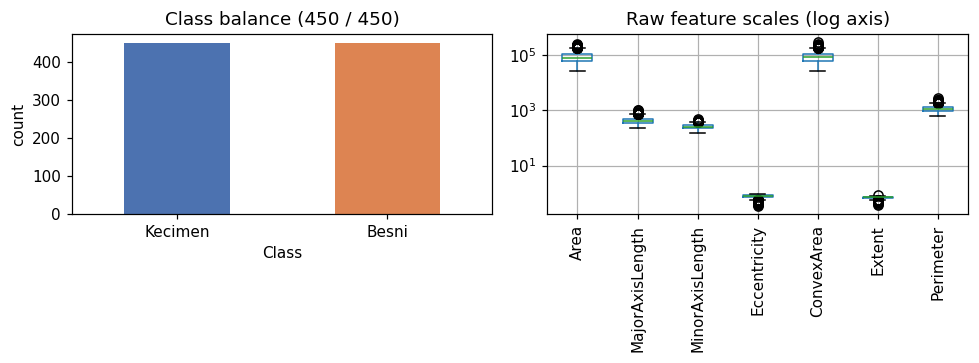

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(9, 3.4))
df["Class"].value_counts().plot.bar(ax=ax[0], color=["#4C72B0", "#DD8452"], rot=0)
ax[0].set_title("Class balance (450 / 450)"); ax[0].set_ylabel("count")
X.boxplot(ax=ax[1], rot=90); ax[1].set_yscale("log")
ax[1].set_title("Raw feature scales (log axis)")
fig.tight_layout(); plt.show()

The right-hand plot is the whole reason scaling matters: `Area` and `ConvexArea` are
four orders of magnitude larger than `Extent` and `Eccentricity`. Without scaling,
those two big columns would dominate every distance calculation and the model would
effectively ignore the rest.

We use one helper to evaluate any model on the test set.

In [6]:
def evaluate(name, model, Xtr, Xte):
    model.fit(Xtr, y_train)
    pred = model.predict(Xte)
    res = dict(name=name, pred=pred,
               acc=accuracy_score(y_test, pred),
               pre=precision_score(y_test, pred),
               rec=recall_score(y_test, pred),
               f1=f1_score(y_test, pred),
               cm=confusion_matrix(y_test, pred))
    print(f"=== {name} ===")
    print(f"Accuracy {res['acc']:.3f} | Precision {res['pre']:.3f} | "
          f"Recall {res['rec']:.3f} | F1 {res['f1']:.3f}\n")
    print(classification_report(y_test, pred, target_names=["Kecimen", "Besni"]))
    return res

## Part B — Support Vector Machine

An SVM finds the boundary that separates the classes with the widest **margin**;
only the points on the edge of that gap (the **support vectors**) decide where it
goes. The **kernel trick** lets it bend that boundary into non-linear shapes. We use
the **RBF kernel** as the default general-purpose choice.

In [7]:
svm = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_STATE)
svm_res = evaluate("SVM (RBF kernel)", svm, X_train_s, X_test_s)

=== SVM (RBF kernel) ===
Accuracy 0.911 | Precision 0.963 | Recall 0.856 | F1 0.906

              precision    recall  f1-score   support

     Kecimen       0.87      0.97      0.92        90
       Besni       0.96      0.86      0.91        90

    accuracy                           0.91       180
   macro avg       0.92      0.91      0.91       180
weighted avg       0.92      0.91      0.91       180



In [8]:
# Kernel check: how does a plain linear kernel compare on this split?
lin = SVC(kernel="linear", C=1.0, random_state=RANDOM_STATE).fit(X_train_s, y_train)
print("Linear-kernel SVM test accuracy:",
      round(accuracy_score(y_test, lin.predict(X_test_s)), 3))

Linear-kernel SVM test accuracy: 0.928


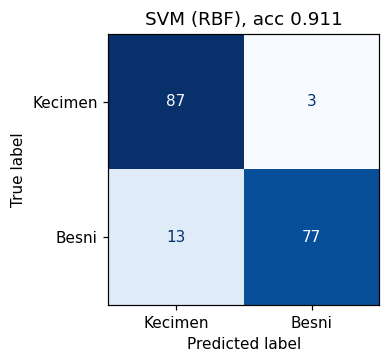

In [9]:
fig, ax = plt.subplots(figsize=(3.8, 3.4))
ConfusionMatrixDisplay(svm_res["cm"], display_labels=["Kecimen", "Besni"]).plot(
    ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"SVM (RBF), acc {svm_res['acc']:.3f}")
fig.tight_layout(); plt.show()

The linear kernel actually edges the RBF on this split (0.928 vs 0.911), so the two
varieties are very nearly linearly separable once scaled. We keep the RBF as the
headline model since it is the more general choice and the gap is within the noise
of one split. High precision (0.963) with lower recall (0.856) means the SVM rarely
calls Besni wrongly, but plays safe and lets a few real Besni through.

**Advantages:** strong in high dimensions, memory-efficient (only support vectors
matter), flexible via kernels. **Limitations:** does not scale to huge datasets,
sensitive to `C`/kernel choice, no probability by default. **Applications:** text and
image classification, bioinformatics, spam filtering, intrusion detection.

## Part C — k-Nearest Neighbors

kNN does no real training. To label a new raisin it finds the **K** closest training
points (Euclidean distance) and takes a majority vote. K is the one knob that
matters, so instead of guessing we sweep K = 1..25 with 5-fold cross-validation.

Best K = 8 (CV accuracy 0.853)


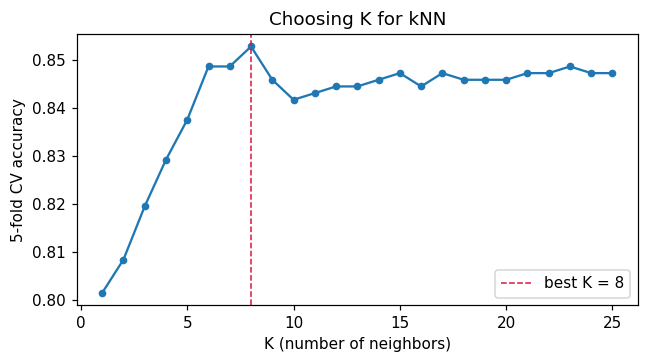

In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
ks = range(1, 26)
k_scores = [cross_val_score(KNeighborsClassifier(n_neighbors=k),
                            X_train_s, y_train, cv=cv, scoring="accuracy").mean()
            for k in ks]
best_k = list(ks)[int(np.argmax(k_scores))]
print(f"Best K = {best_k} (CV accuracy {max(k_scores):.3f})")

fig, ax = plt.subplots(figsize=(6, 3.4))
ax.plot(list(ks), k_scores, marker="o", ms=4)
ax.axvline(best_k, color="crimson", ls="--", lw=1, label=f"best K = {best_k}")
ax.set_xlabel("K (number of neighbors)"); ax.set_ylabel("5-fold CV accuracy")
ax.set_title("Choosing K for kNN"); ax.legend()
fig.tight_layout(); plt.show()

In [11]:
knn = KNeighborsClassifier(n_neighbors=best_k)
knn_res = evaluate(f"kNN (K={best_k})", knn, X_train_s, X_test_s)

=== kNN (K=8) ===
Accuracy 0.861 | Precision 0.945 | Recall 0.767 | F1 0.847

              precision    recall  f1-score   support

     Kecimen       0.80      0.96      0.87        90
       Besni       0.95      0.77      0.85        90

    accuracy                           0.86       180
   macro avg       0.87      0.86      0.86       180
weighted avg       0.87      0.86      0.86       180



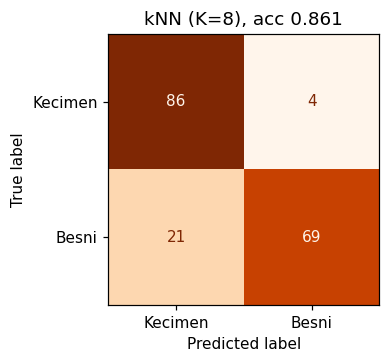

In [12]:
fig, ax = plt.subplots(figsize=(3.8, 3.4))
ConfusionMatrixDisplay(knn_res["cm"], display_labels=["Kecimen", "Besni"]).plot(
    ax=ax, cmap="Oranges", colorbar=False)
ax.set_title(f"kNN (K={best_k}), acc {knn_res['acc']:.3f}")
fig.tight_layout(); plt.show()

Same story as the SVM but stronger: very high precision, lower recall, and 21 Besni
missed against the SVM's 13.

**Advantages:** trivially simple, no training, handles multi-class and non-linear
boundaries. **Limitations:** slow and memory-hungry at prediction time, hurt by the
curse of dimensionality, very sensitive to scaling. **Applications:** recommender
systems, pattern/image recognition, anomaly detection.

## Part D — Comparative Analysis

Side by side on the same test set, then backed up with 5-fold cross-validation on
the full scaled dataset.

In [13]:
def cv_full(model):
    s = cross_val_score(model, StandardScaler().fit_transform(X), y,
                        cv=cv, scoring="accuracy")
    return s.mean(), s.std()

svm_cv = cv_full(SVC(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_STATE))
knn_cv = cv_full(KNeighborsClassifier(n_neighbors=best_k))

summary = pd.DataFrame({
    "Accuracy":  [svm_res["acc"], knn_res["acc"]],
    "Precision": [svm_res["pre"], knn_res["pre"]],
    "Recall":    [svm_res["rec"], knn_res["rec"]],
    "F1":        [svm_res["f1"], knn_res["f1"]],
    "CV acc":    [svm_cv[0], knn_cv[0]],
    "CV std":    [svm_cv[1], knn_cv[1]],
}, index=[svm_res["name"], knn_res["name"]]).round(3)
summary

,Accuracy,Precision,Recall,F1,CV acc,CV std
SVM (RBF kernel),0.911,0.962,0.856,0.906,0.868,0.021
kNN (K=8),0.861,0.945,0.767,0.847,0.847,0.014


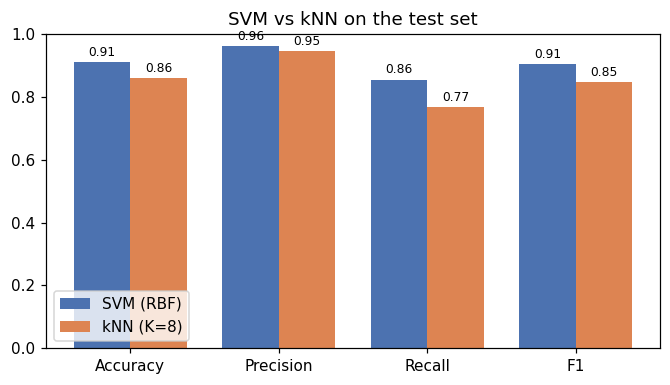

In [14]:
metrics = ["Accuracy", "Precision", "Recall", "F1"]
svm_vals = [svm_res["acc"], svm_res["pre"], svm_res["rec"], svm_res["f1"]]
knn_vals = [knn_res["acc"], knn_res["pre"], knn_res["rec"], knn_res["f1"]]
x = np.arange(len(metrics)); w = 0.38
fig, ax = plt.subplots(figsize=(6.2, 3.6))
b1 = ax.bar(x - w/2, svm_vals, w, label="SVM (RBF)", color="#4C72B0")
b2 = ax.bar(x + w/2, knn_vals, w, label=f"kNN (K={best_k})", color="#DD8452")
ax.set_xticks(x, metrics); ax.set_ylim(0, 1)
ax.set_title("SVM vs kNN on the test set")
ax.bar_label(b1, fmt="%.2f", padding=2, fontsize=8)
ax.bar_label(b2, fmt="%.2f", padding=2, fontsize=8)
ax.legend(); fig.tight_layout(); plt.show()

### Recommendation

**The SVM with an RBF kernel is the better model for this dataset.** It leads on every
headline metric, the whole gap coming from recall (it recovers 77 of 90 Besni against
the kNN's 69), and it keeps that lead under cross-validation (0.868 vs 0.847 mean
accuracy). It also suits the data on principle: with only 7 clean numeric features and
900 rows, this is a small, low-dimensional problem where an SVM is right at home and
where kNN's slow, memory-hungry prediction buys nothing. kNN stays a solid, dead-simple
baseline, and landing within a few points of the SVM shows the two varieties are fairly
easy to separate once the features are scaled.